# Ex1 - Filtering and Sorting Data



### Step 1. Import the necessary libraries

In [1]:
import pandas as pd
import numpy as np

### Step 2. Import the dataset from this [address](https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv) and assign it to a variable called chipo.

In [2]:
url = "https://raw.githubusercontent.com/justmarkham/DAT8/master/data/chipotle.tsv"
chipo = pd.read_csv(url, sep="\t")
chipo

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,$2.39
1,1,1,Izze,[Clementine],$3.39
2,1,1,Nantucket Nectar,[Apple],$3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,$2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",$16.98
...,...,...,...,...,...
4617,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Sour ...",$11.75
4618,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Sour Cream, Cheese...",$11.75
4619,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Pinto...",$11.25
4620,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Lettu...",$8.75


### Step 3. Name of the max valued product

In [3]:
chipo.info()

<class 'pandas.DataFrame'>
RangeIndex: 4622 entries, 0 to 4621
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   order_id            4622 non-null   int64
 1   quantity            4622 non-null   int64
 2   item_name           4622 non-null   str  
 3   choice_description  3376 non-null   str  
 4   item_price          4622 non-null   str  
dtypes: int64(2), str(3)
memory usage: 180.7 KB


In [4]:
chipo.describe()

,order_id,quantity
count,4622.000000,4622.000000
mean,927.254868,1.075725
std,528.890796,0.410186
min,1.000000,1.000000
25%,477.250000,1.000000
50%,926.000000,1.000000
75%,1393.000000,1.000000
max,1834.000000,15.000000


In [5]:
chipo["item_price"]= chipo["item_price"].str.replace("$","").astype(float)
chipo.info()

<class 'pandas.DataFrame'>
RangeIndex: 4622 entries, 0 to 4621
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            4622 non-null   int64  
 1   quantity            4622 non-null   int64  
 2   item_name           4622 non-null   str    
 3   choice_description  3376 non-null   str    
 4   item_price          4622 non-null   float64
dtypes: float64(1), int64(2), str(2)
memory usage: 180.7 KB


<Axes: >

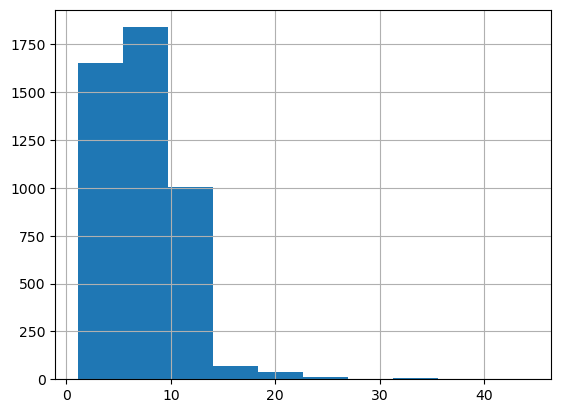

In [6]:
chipo["item_price"].hist()

In [7]:
chipo["item_price"]

0        2.39
1        3.39
2        3.39
3        2.39
4       16.98
        ...  
4617    11.75
4618    11.75
4619    11.25
4620     8.75
4621     8.75
Name: item_price, Length: 4622, dtype: float64

In [8]:
chipo.head()

,order_id,quantity,item_name,choice_description,item_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,2.39
1,1,1,Izze,[Clementine],3.39
2,1,1,Nantucket Nectar,[Apple],3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",16.98


In [9]:
chipo["item_price"].max()
maximo = chipo["item_price"].max()
maximo

np.float64(44.25)

In [10]:
print(maximo)

44.25


In [11]:
chipo[chipo["item_price"] == maximo] # Instrucciones más abajo

,order_id,quantity,item_name,choice_description,item_price
3598,1443,15,Chips and Fresh Tomato Salsa,NaN,44.25


In [12]:
str(chipo[chipo["item_price"] ==chipo["item_price"].max()]["item_name"].values[0]) # Instrucciones más abajo

'Chips and Fresh Tomato Salsa'

In [13]:
'''chipo[chipo["item_price"] == maximo]


Significa: *"dame solo las filas de chipo donde el precio sea igual al máximo"*.

Es decir: **filtra la tabla y muéstrame solo los productos que cuestan 44.25€**.

---

### 📦 Resumen visual:
```
chipo["item_price"] == maximo
→ [False, False, False, ..., True, ..., False]
                                ↑
                    solo esta fila vale 44.25

chipo[ esa_lista_de_true_false ]
→ devuelve solo las filas donde hay True
→ o sea, solo los productos que cuestan 44.25
```

---

# 🔬 PASO 4 — La línea larga: `str(chipo[chipo["item_price"] == chipo["item_price"].max()]["item_name"].values[0])`

Esta línea hace lo mismo pero todo junto, y además extrae el nombre. Vamos trozo a trozo:

---

**Trozo 1:** `chipo["item_price"].max()`
→ calcula el precio máximo. Resultado: `44.25`

---

**Trozo 2:** `chipo["item_price"] == chipo["item_price"].max()`
→ lista de True/False comparando cada precio con 44.25

---

**Trozo 3:** `chipo[ eso ]`
→ filtra la tabla, se queda solo con las filas donde el precio es 44.25
```
order_id | quantity | item_name    | item_price
---------|----------|--------------|----------
404      | 15       | Veggie Salad | 44.25
```

---

**Trozo 4:** `[...]["item_name"]`
→ de esa tabla filtrada, dame solo la columna `item_name`
```
404    Veggie Salad
Name: item_name
```

---

**Trozo 5:** `.values[0]`
→ `.values` convierte la columna en una lista simple: `["Veggie Salad"]`
→ `[0]` coge el primer (y único) elemento: `"Veggie Salad"`

---

**Trozo 6:** `str(...)`
→ convierte el resultado a texto (string), por si acaso tiene algún tipo raro

---

### 📦 Resumen de la línea larga en castellano:
```
"Dame el nombre del producto cuyo precio 
 sea igual al precio máximo de toda la tabla"
```

---

# 💡 La clave que tienes que interiorizar

Esta sintaxis `df[df["columna"] == algo]` es **el filtro más importante de pandas**. Lo vas a usar constantemente. Significa siempre lo mismo:
```
DataFrame [ condición sobre ese mismo DataFrame ]
→ devuelve solo las filas que cumplen la condición
'''


'chipo[chipo["item_price"] == maximo]\n\n\nSignifica: *"dame solo las filas de chipo donde el precio sea igual al máximo"*.\n\nEs decir: **filtra la tabla y muéstrame solo los productos que cuestan 44.25€**.\n\n---\n\n### 📦 Resumen visual:\n```\nchipo["item_price"] == maximo\n→ [False, False, False, ..., True, ..., False]\n                                ↑\n                    solo esta fila vale 44.25\n\nchipo[ esa_lista_de_true_false ]\n→ devuelve solo las filas donde hay True\n→ o sea, solo los productos que cuestan 44.25\n```\n\n---\n\n# 🔬 PASO 4 — La línea larga: `str(chipo[chipo["item_price"] == chipo["item_price"].max()]["item_name"].values[0])`\n\nEsta línea hace lo mismo pero todo junto, y además extrae el nombre. Vamos trozo a trozo:\n\n---\n\n**Trozo 1:** `chipo["item_price"].max()`\n→ calcula el precio máximo. Resultado: `44.25`\n\n---\n\n**Trozo 2:** `chipo["item_price"] == chipo["item_price"].max()`\n→ lista de True/False comparando cada precio con 44.25\n\n---\n\n**Trozo

In [14]:
prod_caro = chipo.loc[(chipo["item_price"]/chipo["quantity"]).idxmax(), "item_name"]
print(prod_caro)

Steak Salad Bowl


In [15]:
'''
chipo.loc[
    (chipo["item_price"] / chipo["quantity"]).idxmax(),
    "item_name"
]
```

Significa:

> 1. Calcula el precio por unidad de cada fila (`item_price / quantity`)
> 2. Encuentra en qué fila ese precio es el más alto (`.idxmax()`)
> 3. Ve a esa fila y dame el nombre del producto (`loc[fila, "item_name"]`)

---

# 🆚 Diferencia entre `.max()` e `.idxmax()`
```
columna de precios: [11.75, 2.95, 10.98, 44.25, 8.75]

.max()    → 44.25   (el valor más alto)
.idxmax() → 3       (la posición donde está ese valor)

'''

'\nchipo.loc[\n    (chipo["item_price"] / chipo["quantity"]).idxmax(),\n    "item_name"\n]\n```\n\nSignifica:\n\n> 1. Calcula el precio por unidad de cada fila (`item_price / quantity`)\n> 2. Encuentra en qué fila ese precio es el más alto (`.idxmax()`)\n> 3. Ve a esa fila y dame el nombre del producto (`loc[fila, "item_name"]`)\n\n---\n\n# 🆚 Diferencia entre `.max()` e `.idxmax()`\n```\ncolumna de precios: [11.75, 2.95, 10.98, 44.25, 8.75]\n\n.max()    → 44.25   (el valor más alto)\n.idxmax() → 3       (la posición donde está ese valor)\n\n'

In [16]:
chipo["item_name"].value_counts()

item_name
Chicken Bowl                             726
Chicken Burrito                          553
Chips and Guacamole                      479
Steak Burrito                            368
Canned Soft Drink                        301
Chips                                    211
Steak Bowl                               211
Bottled Water                            162
Chicken Soft Tacos                       115
Chips and Fresh Tomato Salsa             110
Chicken Salad Bowl                       110
Canned Soda                              104
Side of Chips                            101
Veggie Burrito                            95
Barbacoa Burrito                          91
Veggie Bowl                               85
Carnitas Bowl                             68
Barbacoa Bowl                             66
Carnitas Burrito                          59
Steak Soft Tacos                          55
6 Pack Soft Drink                         54
Chips and Tomatillo Red Chili Salsa       48


In [17]:
chipo[chipo["item_name"]=="Chicken Bowl"]

,order_id,quantity,item_name,choice_description,item_price
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",16.98
5,3,1,Chicken Bowl,"[Fresh Tomato Salsa (Mild), [Rice, Cheese, Sou...",10.98
13,7,1,Chicken Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Rice,...",11.25
19,10,1,Chicken Bowl,"[Tomatillo Red Chili Salsa, [Fajita Vegetables...",8.75
26,13,1,Chicken Bowl,"[Roasted Chili Corn Salsa (Medium), [Pinto Bea...",8.49
...,...,...,...,...,...
4590,1825,1,Chicken Bowl,"[Roasted Chili Corn Salsa, [Rice, Black Beans,...",11.25
4591,1825,1,Chicken Bowl,"[Tomatillo Red Chili Salsa, [Rice, Black Beans...",8.75
4595,1826,1,Chicken Bowl,"[Tomatillo Green Chili Salsa, [Rice, Black Bea...",8.75
4599,1827,1,Chicken Bowl,"[Roasted Chili Corn Salsa, [Cheese, Lettuce]]",8.75


In [18]:
chipo["total_price"]=chipo["item_price"] * chipo["quantity"]
chipo

,order_id,quantity,item_name,choice_description,item_price,total_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,2.39,2.39
1,1,1,Izze,[Clementine],3.39,3.39
2,1,1,Nantucket Nectar,[Apple],3.39,3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,2.39,2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",16.98,33.96
...,...,...,...,...,...,...
4617,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Sour ...",11.75,11.75
4618,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Sour Cream, Cheese...",11.75,11.75
4619,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Pinto...",11.25,11.25
4620,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Lettu...",8.75,8.75


In [19]:
# Buscamos el nombre del producto con el precio total más alto
# Primero filtramos: quedamos solo con las filas donde total_price sea el máximo
# Luego sacamos el nombre del producto
nombre_max = chipo.loc[chipo["total_price"] == chipo["total_price"].max(), "item_name"].values[0]
print("Producto con mayor valor total:", nombre_max)

Producto con mayor valor total: Chips and Fresh Tomato Salsa


In [20]:
chipo['unit_price'] = chipo['item_price'] / chipo['quantity'] # Aquí con ['unit_price'] estás creando una NUEVA COLUMNA de precio unitario
chipo

,order_id,quantity,item_name,choice_description,item_price,total_price,unit_price
0,1,1,Chips and Fresh Tomato Salsa,NaN,2.39,2.39,2.39
1,1,1,Izze,[Clementine],3.39,3.39,3.39
2,1,1,Nantucket Nectar,[Apple],3.39,3.39,3.39
3,1,1,Chips and Tomatillo-Green Chili Salsa,NaN,2.39,2.39,2.39
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",16.98,33.96,8.49
...,...,...,...,...,...,...,...
4617,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Sour ...",11.75,11.75,11.75
4618,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Sour Cream, Cheese...",11.75,11.75,11.75
4619,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Pinto...",11.25,11.25,11.25
4620,1834,1,Chicken Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Lettu...",8.75,8.75,8.75


In [21]:
chipo[chipo["unit_price"]==chipo["unit_price"].max()]

,order_id,quantity,item_name,choice_description,item_price,total_price,unit_price
281,123,2,Steak Salad Bowl,"[Tomatillo Red Chili Salsa, [Black Beans, Chee...",23.78,47.56,11.89
606,250,1,Steak Salad Bowl,"[Fresh Tomato Salsa, [Pinto Beans, Cheese, Gua...",11.89,11.89,11.89
613,253,2,Steak Salad Bowl,"[Tomatillo Red Chili Salsa, [Fajita Vegetables...",23.78,47.56,11.89
749,309,1,Steak Salad Bowl,"[Roasted Chili Corn Salsa, [Rice, Cheese, Lett...",11.89,11.89,11.89
1132,468,1,Carnitas Salad Bowl,"[Fresh Tomato Salsa, [Rice, Black Beans, Chees...",11.89,11.89,11.89
1159,478,1,Steak Salad Bowl,"[Fresh Tomato Salsa, [Rice, Fajita Vegetables,...",11.89,11.89,11.89
1229,501,1,Barbacoa Salad Bowl,"[Fresh Tomato Salsa, [Rice, Fajita Vegetables,...",11.89,11.89,11.89
1311,534,1,Steak Salad Bowl,"[Roasted Chili Corn Salsa, [Fajita Vegetables,...",11.89,11.89,11.89
1326,541,1,Barbacoa Salad Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Rice,...",11.89,11.89,11.89
1505,612,1,Steak Salad Bowl,"[Fresh Tomato Salsa, [Rice, Pinto Beans, Chees...",11.89,11.89,11.89


In [22]:
chipo[chipo["unit_price"]==chipo["unit_price"].max()]["item_name"].unique()

<StringArray>
['Steak Salad Bowl', 'Carnitas Salad Bowl', 'Barbacoa Salad Bowl']
Length: 3, dtype: str

In [23]:
chipo.loc[chipo["unit_price"]==chipo["unit_price"].max(),"item_name"].unique()

<StringArray>
['Steak Salad Bowl', 'Carnitas Salad Bowl', 'Barbacoa Salad Bowl']
Length: 3, dtype: str

In [24]:
chipo["order_id"].value_counts()

order_id
926     23
1483    14
205     12
691     11
759     11
        ..
1593     1
1634     1
1640     1
1767     1
1813     1
Name: count, Length: 1834, dtype: int64

In [25]:
chipo["item_name"].unique()

<StringArray>
[         'Chips and Fresh Tomato Salsa',
                                  'Izze',
                      'Nantucket Nectar',
 'Chips and Tomatillo-Green Chili Salsa',
                          'Chicken Bowl',
                         'Side of Chips',
                         'Steak Burrito',
                      'Steak Soft Tacos',
                   'Chips and Guacamole',
                  'Chicken Crispy Tacos',
                    'Chicken Soft Tacos',
                       'Chicken Burrito',
                           'Canned Soda',
                      'Barbacoa Burrito',
                      'Carnitas Burrito',
                         'Carnitas Bowl',
                         'Bottled Water',
 'Chips and Tomatillo Green Chili Salsa',
                         'Barbacoa Bowl',
                                 'Chips',
                    'Chicken Salad Bowl',
                            'Steak Bowl',
                   'Barbacoa Soft Tacos',
                    

### Step 4. How many products cost more than $10.00?

In [26]:
chipo[chipo["unit_price"]>10]

,order_id,quantity,item_name,choice_description,item_price,total_price,unit_price
5,3,1,Chicken Bowl,"[Fresh Tomato Salsa (Mild), [Rice, Cheese, Sou...",10.98,10.98,10.98
7,4,1,Steak Burrito,"[Tomatillo Red Chili Salsa, [Fajita Vegetables...",11.75,11.75,11.75
13,7,1,Chicken Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Rice,...",11.25,11.25,11.25
23,12,1,Chicken Burrito,"[[Tomatillo-Green Chili Salsa (Medium), Tomati...",10.98,10.98,10.98
39,19,1,Barbacoa Bowl,"[Roasted Chili Corn Salsa, [Fajita Vegetables,...",11.75,11.75,11.75
...,...,...,...,...,...,...,...
4610,1830,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Sour Cream, Cheese...",11.75,11.75,11.75
4611,1830,1,Veggie Burrito,"[Tomatillo Green Chili Salsa, [Rice, Fajita Ve...",11.25,11.25,11.25
4617,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Sour ...",11.75,11.75,11.75
4618,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Sour Cream, Cheese...",11.75,11.75,11.75


In [27]:
chipo[chipo["unit_price"]>10]["item_name"].unique()

<StringArray>
[         'Chicken Bowl',         'Steak Burrito',       'Chicken Burrito',
         'Barbacoa Bowl',        'Veggie Burrito',           'Veggie Bowl',
    'Chicken Soft Tacos',            'Steak Bowl',      'Carnitas Burrito',
         'Carnitas Bowl',      'Barbacoa Burrito',    'Chicken Salad Bowl',
 'Barbacoa Crispy Tacos',     'Veggie Salad Bowl',         'Chicken Salad',
      'Steak Salad Bowl',  'Chicken Crispy Tacos',     'Veggie Soft Tacos',
   'Barbacoa Soft Tacos', 'Carnitas Crispy Tacos',   'Carnitas Salad Bowl',
   'Barbacoa Salad Bowl',      'Steak Soft Tacos',   'Carnitas Soft Tacos',
    'Steak Crispy Tacos']
Length: 25, dtype: str

In [28]:
chipo[chipo["unit_price"]>10]["item_name"].nunique()

25

In [29]:
len(chipo[chipo["item_price"]>10])

1130

In [30]:
chipo[chipo["item_price"]>10].count()

order_id              1130
quantity              1130
item_name             1130
choice_description    1123
item_price            1130
total_price           1130
unit_price            1130
dtype: int64

In [31]:
chipo[chipo["unit_price"]>10]["unit_price"].sum()

np.float64(11773.029999999999)

### Step 4.1: Y cuántos pedidos se han hecho con un producto de más de 10$? Es lo mismo?

In [32]:
chipo[chipo["unit_price"]>10]["order_id"].unique()

array([   3,    4,    7,   12,   19,   20,   21,   24,   26,   27,   28,
         30,   35,   40,   41,   43,   54,   57,   59,   60,   61,   62,
         63,   64,   65,   66,   71,   72,   73,   74,   75,   79,   80,
         83,   84,   86,   89,   90,   93,   94,   95,   99,  103,  107,
        109,  114,  123,  126,  127,  128,  129,  132,  134,  140,  144,
        146,  147,  148,  149,  152,  157,  158,  159,  163,  165,  166,
        168,  170,  171,  174,  175,  176,  177,  178,  179,  180,  186,
        189,  192,  195,  196,  198,  202,  203,  204,  205,  206,  207,
        210,  211,  212,  222,  227,  228,  229,  231,  235,  238,  239,
        241,  242,  243,  245,  248,  250,  253,  256,  258,  261,  262,
        269,  273,  277,  278,  282,  283,  284,  290,  293,  295,  297,
        300,  304,  305,  306,  308,  309,  316,  317,  324,  327,  328,
        329,  337,  338,  339,  341,  343,  347,  350,  356,  357,  358,
        360,  361,  362,  365,  367,  369,  372,  3

In [33]:
len(chipo[chipo["unit_price"]>10]["order_id"].unique())

787

### Step 4.2: Y cuántos pedidos se han hecho de más de 10$? Es lo mismo?

In [34]:
chipo.groupby("order_id")["item_price"].sum().sort_values(ascending=False)

order_id
926     205.25
1443    160.74
1483    139.00
691     118.25
1786    114.30
         ...  
17       10.08
889      10.08
1014     10.08
1303     10.08
1602     10.08
Name: item_price, Length: 1834, dtype: float64

In [35]:
chipo2_1 = chipo.groupby ("order_id")["item_price"].sum().reset_index()
print(chipo2_1)


      order_id  item_price
0            1       11.56
1            2       16.98
2            3       12.67
3            4       21.00
4            5       13.70
...        ...         ...
1829      1830       23.00
1830      1831       12.90
1831      1832       13.20
1832      1833       23.50
1833      1834       28.75

[1834 rows x 2 columns]


In [36]:
orders_sum = chipo.groupby("order_id")["item_price"].sum()
orders_sum

order_id
1       11.56
2       16.98
3       12.67
4       21.00
5       13.70
        ...  
1830    23.00
1831    12.90
1832    13.20
1833    23.50
1834    28.75
Name: item_price, Length: 1834, dtype: float64

In [37]:
len(orders_sum[orders_sum>10])

1834

In [38]:
chipo.groupby("order_id")["item_price"].sum().sort_values(ascending=False).head(20)

order_id
926     205.25
1443    160.74
1483    139.00
691     118.25
1786    114.30
205     109.90
511     104.59
491     102.00
1449     95.39
759      86.30
1454     85.24
1559     82.44
953      81.14
195      81.00
1006     71.40
577      71.15
818      70.85
1660     70.25
1825     66.50
1051     59.35
Name: item_price, dtype: float64

In [39]:
len(chipo.groupby("order_id")["item_price"].sum().sort_values(ascending=False))

1834

In [40]:
chipo.groupby("order_id")["item_price"].sum().sort_values(ascending=False).head(20).index


Index([ 926, 1443, 1483,  691, 1786,  205,  511,  491, 1449,  759, 1454, 1559,
        953,  195, 1006,  577,  818, 1660, 1825, 1051],
      dtype='int64', name='order_id')

In [41]:
top_20_order_ids = chipo.groupby("order_id")["item_price"].sum().sort_values(ascending=False).head(20).index

In [42]:
chipo["order_id"].isin(top_20_order_ids)

0       False
1       False
2       False
3       False
4       False
        ...  
4617    False
4618    False
4619    False
4620    False
4621    False
Name: order_id, Length: 4622, dtype: bool

In [43]:
chipo[chipo["order_id"].isin(top_20_order_ids)]

,order_id,quantity,item_name,choice_description,item_price,total_price,unit_price
448,195,1,Chicken Burrito,"[Fresh Tomato Salsa, [Rice, Cheese, Sour Cream...",8.75,8.75,8.75
449,195,1,Chicken Bowl,"[Fresh Tomato Salsa, [Rice, Black Beans, Chees...",8.75,8.75,8.75
450,195,1,Barbacoa Burrito,"[Fresh Tomato Salsa, [Fajita Vegetables, Rice,...",11.75,11.75,11.75
451,195,1,Chicken Burrito,"[Fresh Tomato Salsa, [Fajita Vegetables, Rice,...",8.75,8.75,8.75
452,195,1,Chicken Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Chees...",11.25,11.25,11.25
...,...,...,...,...,...,...,...
4590,1825,1,Chicken Bowl,"[Roasted Chili Corn Salsa, [Rice, Black Beans,...",11.25,11.25,11.25
4591,1825,1,Chicken Bowl,"[Tomatillo Red Chili Salsa, [Rice, Black Beans...",8.75,8.75,8.75
4592,1825,1,Barbacoa Burrito,"[Tomatillo Red Chili Salsa, [Rice, Fajita Vege...",11.75,11.75,11.75
4593,1825,1,Carnitas Bowl,"[Roasted Chili Corn Salsa, [Rice, Sour Cream, ...",11.75,11.75,11.75


In [44]:
total = 0 
for order_id in chipo["order_id"].unique():
    order = chipo[chipo["order_id"] == order_id]
    amount = order["item_price"].sum()
    if amount > 10:
        #print(f"order_id {order_id} amounts to {amount}")
        total += 1
        
print(total)

1834


### Step 4.3: Y en cuántos pedidos se ha pagado más de 10$ por un mismo producto? Es lo mismo?

In [45]:
chipo[chipo["item_price"]>10]

,order_id,quantity,item_name,choice_description,item_price,total_price,unit_price
4,2,2,Chicken Bowl,"[Tomatillo-Red Chili Salsa (Hot), [Black Beans...",16.98,33.96,8.49
5,3,1,Chicken Bowl,"[Fresh Tomato Salsa (Mild), [Rice, Cheese, Sou...",10.98,10.98,10.98
7,4,1,Steak Burrito,"[Tomatillo Red Chili Salsa, [Fajita Vegetables...",11.75,11.75,11.75
13,7,1,Chicken Bowl,"[Fresh Tomato Salsa, [Fajita Vegetables, Rice,...",11.25,11.25,11.25
23,12,1,Chicken Burrito,"[[Tomatillo-Green Chili Salsa (Medium), Tomati...",10.98,10.98,10.98
...,...,...,...,...,...,...,...
4610,1830,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Sour Cream, Cheese...",11.75,11.75,11.75
4611,1830,1,Veggie Burrito,"[Tomatillo Green Chili Salsa, [Rice, Fajita Ve...",11.25,11.25,11.25
4617,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Black Beans, Sour ...",11.75,11.75,11.75
4618,1833,1,Steak Burrito,"[Fresh Tomato Salsa, [Rice, Sour Cream, Cheese...",11.75,11.75,11.75


In [46]:
chipo[chipo["item_price"]>10]["order_id"].nunique()

863

### Step 5. What is the price of each item and name it unit_price. Get only item_name and unit_price

In [47]:
chipo.loc[:,['item_name','unit_price']]

,item_name,unit_price
0,Chips and Fresh Tomato Salsa,2.39
1,Izze,3.39
2,Nantucket Nectar,3.39
3,Chips and Tomatillo-Green Chili Salsa,2.39
4,Chicken Bowl,8.49
...,...,...
4617,Steak Burrito,11.75
4618,Steak Burrito,11.75
4619,Chicken Salad Bowl,11.25
4620,Chicken Salad Bowl,8.75


In [48]:
# Se puede hacer también: 
chipo[["item_name", "unit_price"]]

,item_name,unit_price
0,Chips and Fresh Tomato Salsa,2.39
1,Izze,3.39
2,Nantucket Nectar,3.39
3,Chips and Tomatillo-Green Chili Salsa,2.39
4,Chicken Bowl,8.49
...,...,...
4617,Steak Burrito,11.75
4618,Steak Burrito,11.75
4619,Chicken Salad Bowl,11.25
4620,Chicken Salad Bowl,8.75


In [49]:
chipo.loc[:,['item_name','unit_price']].drop_duplicates()

,item_name,unit_price
0,Chips and Fresh Tomato Salsa,2.39
1,Izze,3.39
2,Nantucket Nectar,3.39
3,Chips and Tomatillo-Green Chili Salsa,2.39
4,Chicken Bowl,8.49
...,...,...
3989,Chicken Salad,8.19
4235,Chicken Bowl,8.50
4237,Chips and Guacamole,4.25
4509,Chips,1.99


In [50]:
len(chipo.loc[:,['item_name','unit_price']].drop_duplicates())

139

In [51]:
chipo['item_name'].nunique()

50

### Step 6. Sort by the name of the item

In [52]:
chipo.sort_values("item_name",ascending=False)

,order_id,quantity,item_name,choice_description,item_price,total_price,unit_price
3889,1559,2,Veggie Soft Tacos,"[Fresh Tomato Salsa (Mild), [Black Beans, Rice...",16.98,33.96,8.49
2851,1132,1,Veggie Soft Tacos,"[Roasted Chili Corn Salsa (Medium), [Black Bea...",8.49,8.49,8.49
738,304,1,Veggie Soft Tacos,"[Tomatillo Red Chili Salsa, [Fajita Vegetables...",11.25,11.25,11.25
1395,567,1,Veggie Soft Tacos,"[Fresh Tomato Salsa (Mild), [Pinto Beans, Rice...",8.49,8.49,8.49
2384,948,1,Veggie Soft Tacos,"[Roasted Chili Corn Salsa, [Fajita Vegetables,...",8.75,8.75,8.75
...,...,...,...,...,...,...,...
1916,774,1,6 Pack Soft Drink,[Diet Coke],6.49,6.49,6.49
1124,465,1,6 Pack Soft Drink,[Coke],6.49,6.49,6.49
3789,1517,1,6 Pack Soft Drink,[Diet Coke],6.49,6.49,6.49
1392,566,1,6 Pack Soft Drink,[Diet Coke],6.49,6.49,6.49


In [53]:
chipo.sort_values(['item_name','item_price'], ascending=[False, True])

,order_id,quantity,item_name,choice_description,item_price,total_price,unit_price
1395,567,1,Veggie Soft Tacos,"[Fresh Tomato Salsa (Mild), [Pinto Beans, Rice...",8.49,8.49,8.49
2851,1132,1,Veggie Soft Tacos,"[Roasted Chili Corn Salsa (Medium), [Black Bea...",8.49,8.49,8.49
781,322,1,Veggie Soft Tacos,"[Fresh Tomato Salsa, [Black Beans, Cheese, Sou...",8.75,8.75,8.75
2384,948,1,Veggie Soft Tacos,"[Roasted Chili Corn Salsa, [Fajita Vegetables,...",8.75,8.75,8.75
738,304,1,Veggie Soft Tacos,"[Tomatillo Red Chili Salsa, [Fajita Vegetables...",11.25,11.25,11.25
...,...,...,...,...,...,...,...
4363,1742,1,6 Pack Soft Drink,[Diet Coke],6.49,6.49,6.49
4522,1798,1,6 Pack Soft Drink,[Diet Coke],6.49,6.49,6.49
4527,1800,1,6 Pack Soft Drink,[Diet Coke],6.49,6.49,6.49
4535,1803,1,6 Pack Soft Drink,[Lemonade],6.49,6.49,6.49


### Step 7. What was the quantity of the most expensive item ordered? 2 ways

In [54]:
max_valued_products = chipo[chipo['unit_price'] == chipo['unit_price'].max()]['item_name'].unique()
max_valued_products

<StringArray>
['Steak Salad Bowl', 'Carnitas Salad Bowl', 'Barbacoa Salad Bowl']
Length: 3, dtype: str

In [55]:
for m in max_valued_products:
    print(m)
    print(chipo[chipo['item_name']==m]['quantity'].sum())
    print()

Steak Salad Bowl
31

Carnitas Salad Bowl
6

Barbacoa Salad Bowl
10



In [56]:
chipo[chipo['unit_price'] == chipo['unit_price'].max()]['item_name']

281        Steak Salad Bowl
606        Steak Salad Bowl
613        Steak Salad Bowl
749        Steak Salad Bowl
1132    Carnitas Salad Bowl
1159       Steak Salad Bowl
1229    Barbacoa Salad Bowl
1311       Steak Salad Bowl
1326    Barbacoa Salad Bowl
1505       Steak Salad Bowl
1571       Steak Salad Bowl
1590       Steak Salad Bowl
1816       Steak Salad Bowl
2401       Steak Salad Bowl
2439       Steak Salad Bowl
2442    Barbacoa Salad Bowl
2610    Carnitas Salad Bowl
2740       Steak Salad Bowl
2804       Steak Salad Bowl
2957       Steak Salad Bowl
3120       Steak Salad Bowl
3208    Barbacoa Salad Bowl
3350       Steak Salad Bowl
3493       Steak Salad Bowl
3546    Barbacoa Salad Bowl
3749    Carnitas Salad Bowl
4239    Carnitas Salad Bowl
4313       Steak Salad Bowl
Name: item_name, dtype: str

In [57]:
chipo[chipo['unit_price'] == chipo['unit_price'].max()].groupby("item_name").sum()

,order_id,quantity,choice_description,item_price,total_price,unit_price
item_name,,,,,,
Barbacoa Salad Bowl,4721,5,"[Fresh Tomato Salsa, [Rice, Fajita Vegetables,...",59.45,59.45,59.45
Carnitas Salad Bowl,4694,4,"[Fresh Tomato Salsa, [Rice, Black Beans, Chees...",47.56,47.56,47.56
Steak Salad Bowl,15584,21,"[Tomatillo Red Chili Salsa, [Black Beans, Chee...",249.69,297.25,225.91


### Step 8. How many times was a Veggie Salad Bowl ordered?

In [58]:
chipo[chipo["item_name"]=="Veggie Salad Bowl"]["quantity"].sum()

np.int64(18)

In [59]:
chipo.loc[chipo['item_name'] == "Veggie Salad Bowl",'quantity'].sum()

np.int64(18)

In [60]:
chipo.loc[chipo['item_name'] == "Veggie Salad Bowl",['quantity','item_price']].sum()

quantity       18.0
item_price    182.5
dtype: float64

### Step 9. How many times did someone order more than one Canned Soda?

In [61]:
chipo[(chipo['item_name'] == "Canned Soda") & (chipo['quantity'] > 1)]['order_id'].nunique()

18

In [62]:
# Filtramos: queremos las filas donde el producto sea "Canned Soda" Y la cantidad sea mayor que 1
# & une dos condiciones (las dos tienen que cumplirse)
# .shape[0] nos dice cuántas filas tiene el resultado (cuántas veces pasó)
veces = chipo[(chipo["item_name"] == "Canned Soda") & (chipo["quantity"] > 1)].shape[0]
print(f"Alguien pidió más de una Canned Soda {veces} veces")

Alguien pidió más de una Canned Soda 20 veces
